# Geospatial Data Analysis for Infrastructure Planning

This project analyzes NYC collision data to identify crash patterns, contributing factors, vehicle involvement, borough-level severity, and spatial hotspots.  
The goal is to support data-driven infrastructure planning and safety improvement decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

## 1. Load the Dataset

The dataset contains NYC collision records with date, time, location, injury counts, contributing factors, vehicle types, borough, and ZIP code information.

In [2]:
crashes = pd.read_csv(r"C:\Users\rpere\OneDrive\Desktop\Geospatial_Data_Analysis_Project\data_cleaned\nyc_collisions_clean.csv")
crashes.head()

,crash_date,crash_time,latitude,longitude,on_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,vehicle_type_code1,borough,zip_code
0,01-01-2021,20:00,40.83398,-73.826350,BRUCKNER EXPRESSWAY,NaN,0,0,0,0,0,0,0,Pavement Slippery,Station Wagon/Sport Utility Vehicle,NaN,NaN
1,01-01-2021,05:28,40.68730,-73.973656,LAFAYETTE AVENUE,NaN,0,0,0,0,0,0,0,Unspecified,Sedan,NaN,NaN
2,01-01-2021,06:00,NaN,NaN,WEST SHORE EXPRESSWAY,NaN,0,0,0,0,0,0,0,Fell Asleep,Sedan,NaN,NaN
3,01-01-2021,19:30,40.88270,-73.892730,SEDGWICK AVENUE,NaN,0,0,0,0,0,0,0,NaN,NaN,BRONX,10463.0
4,01-01-2021,07:40,40.63791,-73.978640,CORTELYOU ROAD,NaN,0,0,0,0,0,0,0,Unspecified,Station Wagon/Sport Utility Vehicle,BROOKLYN,11218.0


In [3]:
print("Shape of dataset:", crashes.shape)
print("\nColumns:\n")
print(crashes.columns.tolist())

Shape of dataset: (505949, 17)

Columns:

['crash_date', 'crash_time', 'latitude', 'longitude', 'on_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'vehicle_type_code1', 'borough', 'zip_code']


## 2. Standardize Column Names

To avoid column-name errors, all column names are cleaned by:
- converting to lowercase
- replacing spaces with underscores
- removing leading and trailing spaces

In [4]:
crashes.columns = crashes.columns.str.strip().str.lower().str.replace(" ", "_")
print(crashes.columns.tolist())

['crash_date', 'crash_time', 'latitude', 'longitude', 'on_street_name', 'number_of_persons_injured', 'number_of_persons_killed', 'number_of_pedestrians_injured', 'number_of_pedestrians_killed', 'number_of_cyclist_injured', 'number_of_cyclist_killed', 'number_of_motorist_injured', 'number_of_motorist_killed', 'contributing_factor_vehicle_1', 'vehicle_type_code1', 'borough', 'zip_code']


## 3. Select Relevant Columns

Only the most useful columns are kept for analysis.  
Columns with excessive missing values and limited analytical value are excluded.

In [5]:
crashes = crashes[
    [
        'crash_date',
        'crash_time',
        'latitude',
        'longitude',
        'on_street_name',
        'number_of_persons_injured',
        'number_of_persons_killed',
        'number_of_pedestrians_injured',
        'number_of_pedestrians_killed',
        'number_of_cyclist_injured',
        'number_of_cyclist_killed',
        'number_of_motorist_injured',
        'number_of_motorist_killed',
        'contributing_factor_vehicle_1',
        'vehicle_type_code1',
        'borough',
        'zip_code'
    ]
].copy()

crashes.head()

,crash_date,crash_time,latitude,longitude,on_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,vehicle_type_code1,borough,zip_code
0,01-01-2021,20:00,40.83398,-73.826350,BRUCKNER EXPRESSWAY,NaN,0,0,0,0,0,0,0,Pavement Slippery,Station Wagon/Sport Utility Vehicle,NaN,NaN
1,01-01-2021,05:28,40.68730,-73.973656,LAFAYETTE AVENUE,NaN,0,0,0,0,0,0,0,Unspecified,Sedan,NaN,NaN
2,01-01-2021,06:00,NaN,NaN,WEST SHORE EXPRESSWAY,NaN,0,0,0,0,0,0,0,Fell Asleep,Sedan,NaN,NaN
3,01-01-2021,19:30,40.88270,-73.892730,SEDGWICK AVENUE,NaN,0,0,0,0,0,0,0,NaN,NaN,BRONX,10463.0
4,01-01-2021,07:40,40.63791,-73.978640,CORTELYOU ROAD,NaN,0,0,0,0,0,0,0,Unspecified,Station Wagon/Sport Utility Vehicle,BROOKLYN,11218.0


## 4. Clean the Data

The data is cleaned by:
- removing duplicate records
- converting latitude and longitude to numeric format
- removing rows with missing coordinates
- filling missing categorical values
- filling missing injury and fatality counts with zero

In [6]:
crashes = crashes.drop_duplicates().copy()

crashes['latitude'] = pd.to_numeric(crashes['latitude'], errors='coerce')
crashes['longitude'] = pd.to_numeric(crashes['longitude'], errors='coerce')

crashes = crashes.dropna(subset=['latitude', 'longitude']).copy()

crashes['borough'] = crashes['borough'].fillna('Unknown')
crashes['contributing_factor_vehicle_1'] = crashes['contributing_factor_vehicle_1'].fillna('Unknown')
crashes['vehicle_type_code1'] = crashes['vehicle_type_code1'].fillna('Unknown')

injury_cols = [
    'number_of_persons_injured',
    'number_of_persons_killed',
    'number_of_pedestrians_injured',
    'number_of_pedestrians_killed',
    'number_of_cyclist_injured',
    'number_of_cyclist_killed',
    'number_of_motorist_injured',
    'number_of_motorist_killed'
]

crashes[injury_cols] = crashes[injury_cols].fillna(0)

crashes.head()

,crash_date,crash_time,latitude,longitude,on_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,number_of_cyclist_killed,number_of_motorist_injured,number_of_motorist_killed,contributing_factor_vehicle_1,vehicle_type_code1,borough,zip_code
0,01-01-2021,20:00,40.83398,-73.826350,BRUCKNER EXPRESSWAY,0.0,0,0,0,0,0,0,0,Pavement Slippery,Station Wagon/Sport Utility Vehicle,Unknown,NaN
1,01-01-2021,05:28,40.68730,-73.973656,LAFAYETTE AVENUE,0.0,0,0,0,0,0,0,0,Unspecified,Sedan,Unknown,NaN
3,01-01-2021,19:30,40.88270,-73.892730,SEDGWICK AVENUE,0.0,0,0,0,0,0,0,0,Unknown,Unknown,BRONX,10463.0
4,01-01-2021,07:40,40.63791,-73.978640,CORTELYOU ROAD,0.0,0,0,0,0,0,0,0,Unspecified,Station Wagon/Sport Utility Vehicle,BROOKLYN,11218.0
5,01-01-2021,18:45,40.84863,-73.927620,HARLEM RIVER DRIVE,0.0,0,0,0,0,0,0,0,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Sedan,Unknown,NaN


In [7]:
crashes.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 472517 entries, 0 to 505948
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     472517 non-null  object 
 1   crash_time                     472517 non-null  object 
 2   latitude                       472517 non-null  float64
 3   longitude                      472517 non-null  float64
 4   on_street_name                 333256 non-null  object 
 5   number_of_persons_injured      472517 non-null  float64
 6   number_of_persons_killed       472517 non-null  int64  
 7   number_of_pedestrians_injured  472517 non-null  int64  
 8   number_of_pedestrians_killed   472517 non-null  int64  
 9   number_of_cyclist_injured      472517 non-null  int64  
 10  number_of_cyclist_killed       472517 non-null  int64  
 11  number_of_motorist_injured     472517 non-null  int64  
 12  number_of_motorist_killed     

### Data Cleaning Insight

The dataset has been prepared for analysis by removing invalid coordinate records and handling missing categorical and numerical values.  
This improves reliability for trend analysis, borough comparisons, and geospatial visualization.

## 5. Feature Engineering

New analytical features are created to support time-based and severity-based analysis:
- crash year
- crash month
- day name
- total casualties
- severity category

In [8]:
crashes['crash_date'] = pd.to_datetime(crashes['crash_date'], errors='coerce')
crashes = crashes.dropna(subset=['crash_date']).copy()

crashes['year'] = crashes['crash_date'].dt.year
crashes['month'] = crashes['crash_date'].dt.month
crashes['day_name'] = crashes['crash_date'].dt.day_name()

crashes['total_casualties'] = (
    crashes['number_of_persons_injured'] +
    crashes['number_of_persons_killed']
)

crashes['severity'] = np.where(crashes['total_casualties'] >= 3, 'High', 'Low')

crashes.head()

,crash_date,crash_time,latitude,longitude,on_street_name,number_of_persons_injured,number_of_persons_killed,number_of_pedestrians_injured,number_of_pedestrians_killed,number_of_cyclist_injured,...,number_of_motorist_killed,contributing_factor_vehicle_1,vehicle_type_code1,borough,zip_code,year,month,day_name,total_casualties,severity
0,2021-01-01,20:00,40.83398,-73.826350,BRUCKNER EXPRESSWAY,0.0,0,0,0,0,...,0,Pavement Slippery,Station Wagon/Sport Utility Vehicle,Unknown,NaN,2021,1,Friday,0.0,Low
1,2021-01-01,05:28,40.68730,-73.973656,LAFAYETTE AVENUE,0.0,0,0,0,0,...,0,Unspecified,Sedan,Unknown,NaN,2021,1,Friday,0.0,Low
3,2021-01-01,19:30,40.88270,-73.892730,SEDGWICK AVENUE,0.0,0,0,0,0,...,0,Unknown,Unknown,BRONX,10463.0,2021,1,Friday,0.0,Low
4,2021-01-01,07:40,40.63791,-73.978640,CORTELYOU ROAD,0.0,0,0,0,0,...,0,Unspecified,Station Wagon/Sport Utility Vehicle,BROOKLYN,11218.0,2021,1,Friday,0.0,Low
5,2021-01-01,18:45,40.84863,-73.927620,HARLEM RIVER DRIVE,0.0,0,0,0,0,...,0,Pedestrian/Bicyclist/Other Pedestrian Error/Co...,Sedan,Unknown,NaN,2021,1,Friday,0.0,Low


### Feature Engineering Insight

The derived variables make it possible to analyze how crashes vary across time and how severe incidents are distributed across boroughs.

## 6. Crash Volume by Borough

In [11]:
borough_counts_clean = crashes[crashes['borough'] != 'Unknown']['borough'].value_counts()
borough_counts_clean

BROOKLYN         121494
QUEENS            93412
MANHATTAN         61483
BRONX             57302
STATEN ISLAND     13851
Name: borough, dtype: int64

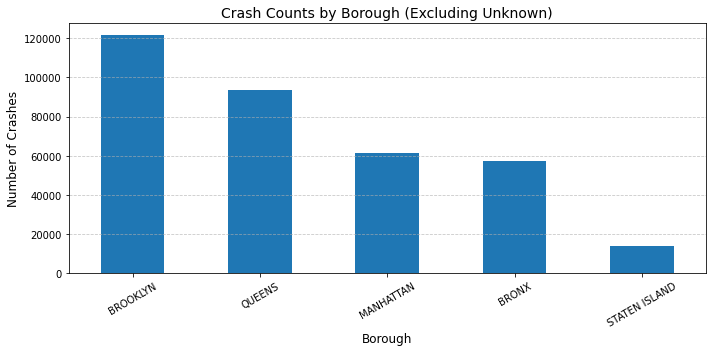

In [13]:
plt.figure(figsize=(10,5))
borough_counts_clean.plot(kind='bar')

plt.title('Crash Counts by Borough (Excluding Unknown)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Number of Crashes', fontsize=12)

plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Borough-Level Crash Analysis Insight

Brooklyn and Queens report the highest number of crashes, indicating high traffic density and infrastructure stress in these areas.  
Manhattan and the Bronx show moderate crash volumes, while Staten Island has significantly fewer incidents.

This suggests that densely populated and high-mobility boroughs experience greater collision frequency, highlighting the need for targeted traffic management and safety interventions in these regions.

## 7. Monthly Crash Trend

In [14]:
monthly_trend = crashes.groupby('month').size().sort_index()
monthly_trend

month
1     41616
2     36672
3     40969
4     37434
5     41142
6     40467
7     39535
8     38469
9     38967
10    40445
11    38392
12    38409
dtype: int64

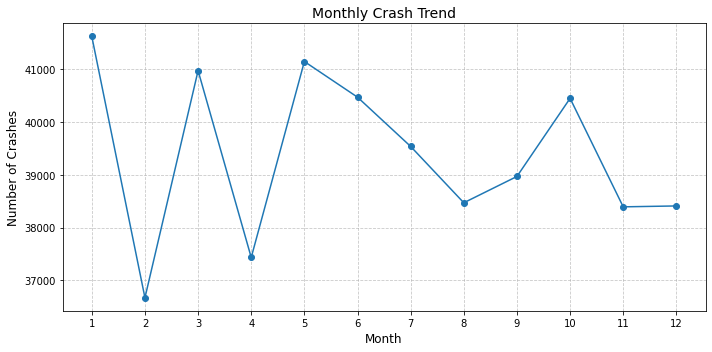

In [16]:
plt.figure(figsize=(10,5))

monthly_trend.plot(kind='line', marker='o')

plt.title('Monthly Crash Trend', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Crashes', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1,13))

plt.tight_layout()
plt.show()

### Monthly Crash Trend Insight

The monthly crash trend shows noticeable fluctuations throughout the year.  
Crash counts appear to peak during certain months, while dropping in others.

This variation may be influenced by:
- seasonal weather conditions
- traffic volume changes
- holiday travel patterns

These insights can support time-based planning for road safety measures, traffic enforcement, and infrastructure maintenance.

## 8. Top Contributing Factors

In [19]:
top_factors_clean = crashes[
    crashes['contributing_factor_vehicle_1'] != 'Unspecified'
]['contributing_factor_vehicle_1'].value_counts().head(10)

top_factors_clean

Driver Inattention/Distraction    116305
Failure to Yield Right-of-Way      32795
Following Too Closely              26620
Passing or Lane Usage Improper     19972
Passing Too Closely                17104
Unsafe Speed                       16658
Backing Unsafely                   14965
Other Vehicular                    14568
Traffic Control Disregarded        13207
Turning Improperly                 10967
Name: contributing_factor_vehicle_1, dtype: int64

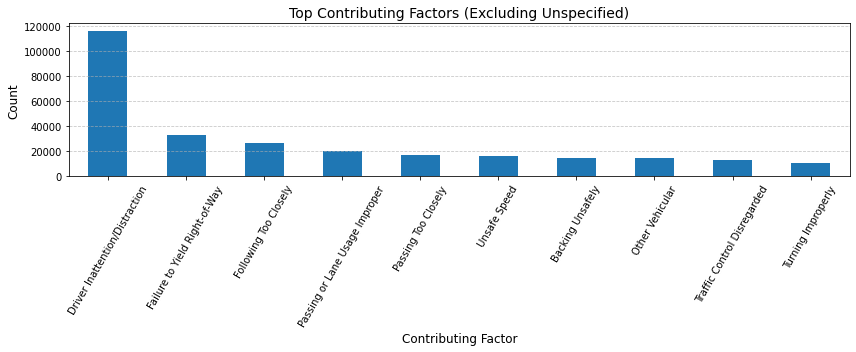

In [20]:
plt.figure(figsize=(12,5))

top_factors_clean.plot(kind='bar')

plt.title('Top Contributing Factors (Excluding Unspecified)', fontsize=14)
plt.xlabel('Contributing Factor', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Contributing Factor Analysis Insight

After removing "Unspecified" entries, the analysis reveals that the leading causes of accidents are primarily related to driver behavior.

Driver inattention or distraction is the most significant contributing factor, followed by failure to yield right-of-way and unsafe following distances.

These findings indicate that human error is the dominant cause of traffic incidents, suggesting that improved driver awareness, stricter enforcement, and safety campaigns could significantly reduce accident rates.

## 9. Top Vehicle Types Involved

In [23]:
top_vehicle_types_clean = crashes[
    crashes['vehicle_type_code1'] != 'Unknown'
]['vehicle_type_code1'].value_counts().head(10)

top_vehicle_types_clean

Sedan                                  217633
Station Wagon/Sport Utility Vehicle    163279
Taxi                                    12958
Pick-up Truck                           10629
Bus                                      8853
Bike                                     8004
Box Truck                                7682
Motorcycle                               4352
E-Bike                                   3840
Tractor Truck Diesel                     3173
Name: vehicle_type_code1, dtype: int64

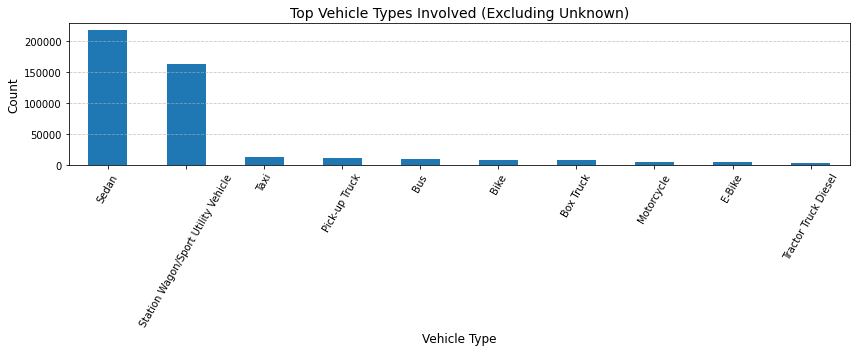

In [24]:
plt.figure(figsize=(12,5))

top_vehicle_types_clean.plot(kind='bar')

plt.title('Top Vehicle Types Involved (Excluding Unknown)', fontsize=14)
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xticks(rotation=60)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Vehicle Type Analysis Insight

After excluding records with unknown vehicle types, the analysis shows that sedans and SUVs dominate accident involvement.

This reflects high usage of private vehicles in urban areas.  
Commercial vehicles such as taxis, buses, and trucks also contribute significantly to accident occurrences.

These findings highlight the impact of traffic density and mixed vehicle usage on road safety.

## 10. Severity Analysis by Borough

In [26]:
severity_by_borough_clean = crashes[
    crashes['borough'] != 'Unknown'
].groupby('borough')['total_casualties'].sum().sort_values(ascending=False)

severity_by_borough_clean

borough
BROOKLYN         262.0
QUEENS           183.0
MANHATTAN        139.0
BRONX            132.0
STATEN ISLAND     34.0
Name: total_casualties, dtype: float64

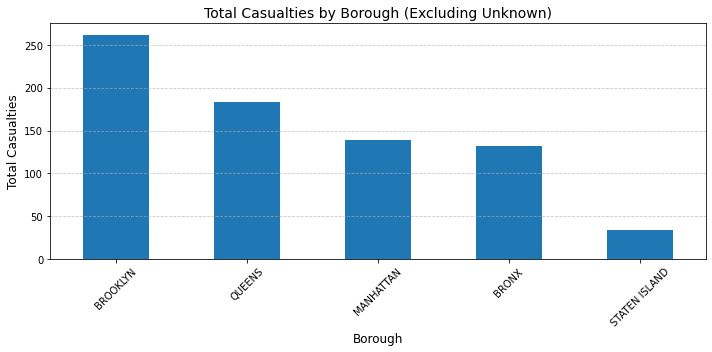

In [27]:
plt.figure(figsize=(10,5))

severity_by_borough_clean.plot(kind='bar')

plt.title('Total Casualties by Borough (Excluding Unknown)', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Casualties', fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Severity Analysis Insight

After excluding records with missing borough information, the analysis shows that Brooklyn and Queens have the highest total casualties.

This indicates that these boroughs not only experience a high number of crashes but also more severe incidents, making them priority areas for infrastructure improvement and safety interventions.

Lower casualty counts in Staten Island suggest comparatively lower traffic density and reduced accident severity.

## 11. Interactive Geospatial Map

A sample of records is used to generate an interactive map for visualizing crash locations.  
This helps reveal the spatial spread of incidents across NYC.

In [28]:
sample_crashes = crashes.sample(1000, random_state=42).copy()

map_center = [sample_crashes['latitude'].mean(), sample_crashes['longitude'].mean()]
crash_map = folium.Map(location=map_center, zoom_start=10)

In [29]:
for _, row in sample_crashes.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        popup=f"{row['borough']} | Casualties: {row['total_casualties']}",
        fill=True
    ).add_to(crash_map)

crash_map

### Geospatial Analysis Insight

The interactive map reveals a high concentration of crash incidents in Brooklyn, Queens, and Manhattan.

These clusters indicate traffic hotspots where accident frequency is significantly higher.  
This pattern reflects dense urban activity, high vehicle volume, and complex traffic conditions.

Such spatial insights can support:
- targeted infrastructure improvements  
- traffic signal optimization  
- accident prevention strategies  
- better urban planning decisions

In [30]:
crash_map.save(r"C:\Users\rpere\Downloads\crash_map.html")

## 12. Save Cleaned Dataset

In [31]:
crashes.to_csv(r"C:\Users\rpere\Downloads\crashes_cleaned_final.csv", index=False)

## Final Conclusion

This project analyzed NYC collision data to uncover key patterns in crash frequency, contributing factors, vehicle involvement, and geographic distribution.

Key findings include:
- Brooklyn and Queens have the highest crash counts and total casualties, indicating areas of high traffic density and infrastructure stress.
- Crash frequency varies across months, suggesting the influence of seasonal patterns and traffic behavior.
- Driver-related factors such as inattention, failure to yield, and unsafe following distance are the leading causes of accidents.
- Sedans and SUVs are most frequently involved in collisions, reflecting the dominance of private vehicles in urban traffic.
- Geospatial analysis revealed clear accident hotspots in densely populated boroughs.

Overall, the analysis highlights that both traffic volume and human behavior significantly impact road safety.  
These insights can support data-driven decisions for infrastructure planning, traffic management, and accident prevention strategies.

## Resume-Ready Project Summary

**Geospatial Data Analysis for Infrastructure Planning**

- Analyzed NYC collision dataset using Python (Pandas, NumPy, Matplotlib, Folium) to identify crash patterns, severity trends, and geographic hotspots.
- Performed data cleaning and preprocessing, handling missing values and removing irrelevant data to ensure accurate analysis.
- Conducted exploratory data analysis to evaluate borough-level crash distribution, monthly trends, contributing factors, and vehicle involvement.
- Developed an interactive geospatial map using Folium to visualize accident hotspots and support location-based decision-making.
- Generated actionable insights to support infrastructure planning, traffic safety improvements, and urban resource allocation.